# Satellite Image Analysis for Natural Disaster Prediction

**Option 2 — Flood + wildfire detection, change detection, prediction, and damage assessment.**

This notebook walks through the full pipeline in order:

1. Kaggle dataset setup
2. Inspect the downloaded folder layout
3. Install remaining dependencies
4. Train the FloodNet U-Net (change/segmentation model)
5. Evaluate the trained model
6. Benchmark int8 quantization (compute-constraint tradeoff)
7. Flood risk *prediction* (precursor-signal prototype)
8. Unified system demo — flood before/after, fast vs. accurate mode
9. Wildfire burn-severity demo (dNBR, tiered severity)
10. Google Earth Engine — live time-series + before/after pull

> Run cells top to bottom. Shell commands (`!...`) work the same in Jupyter as in Colab.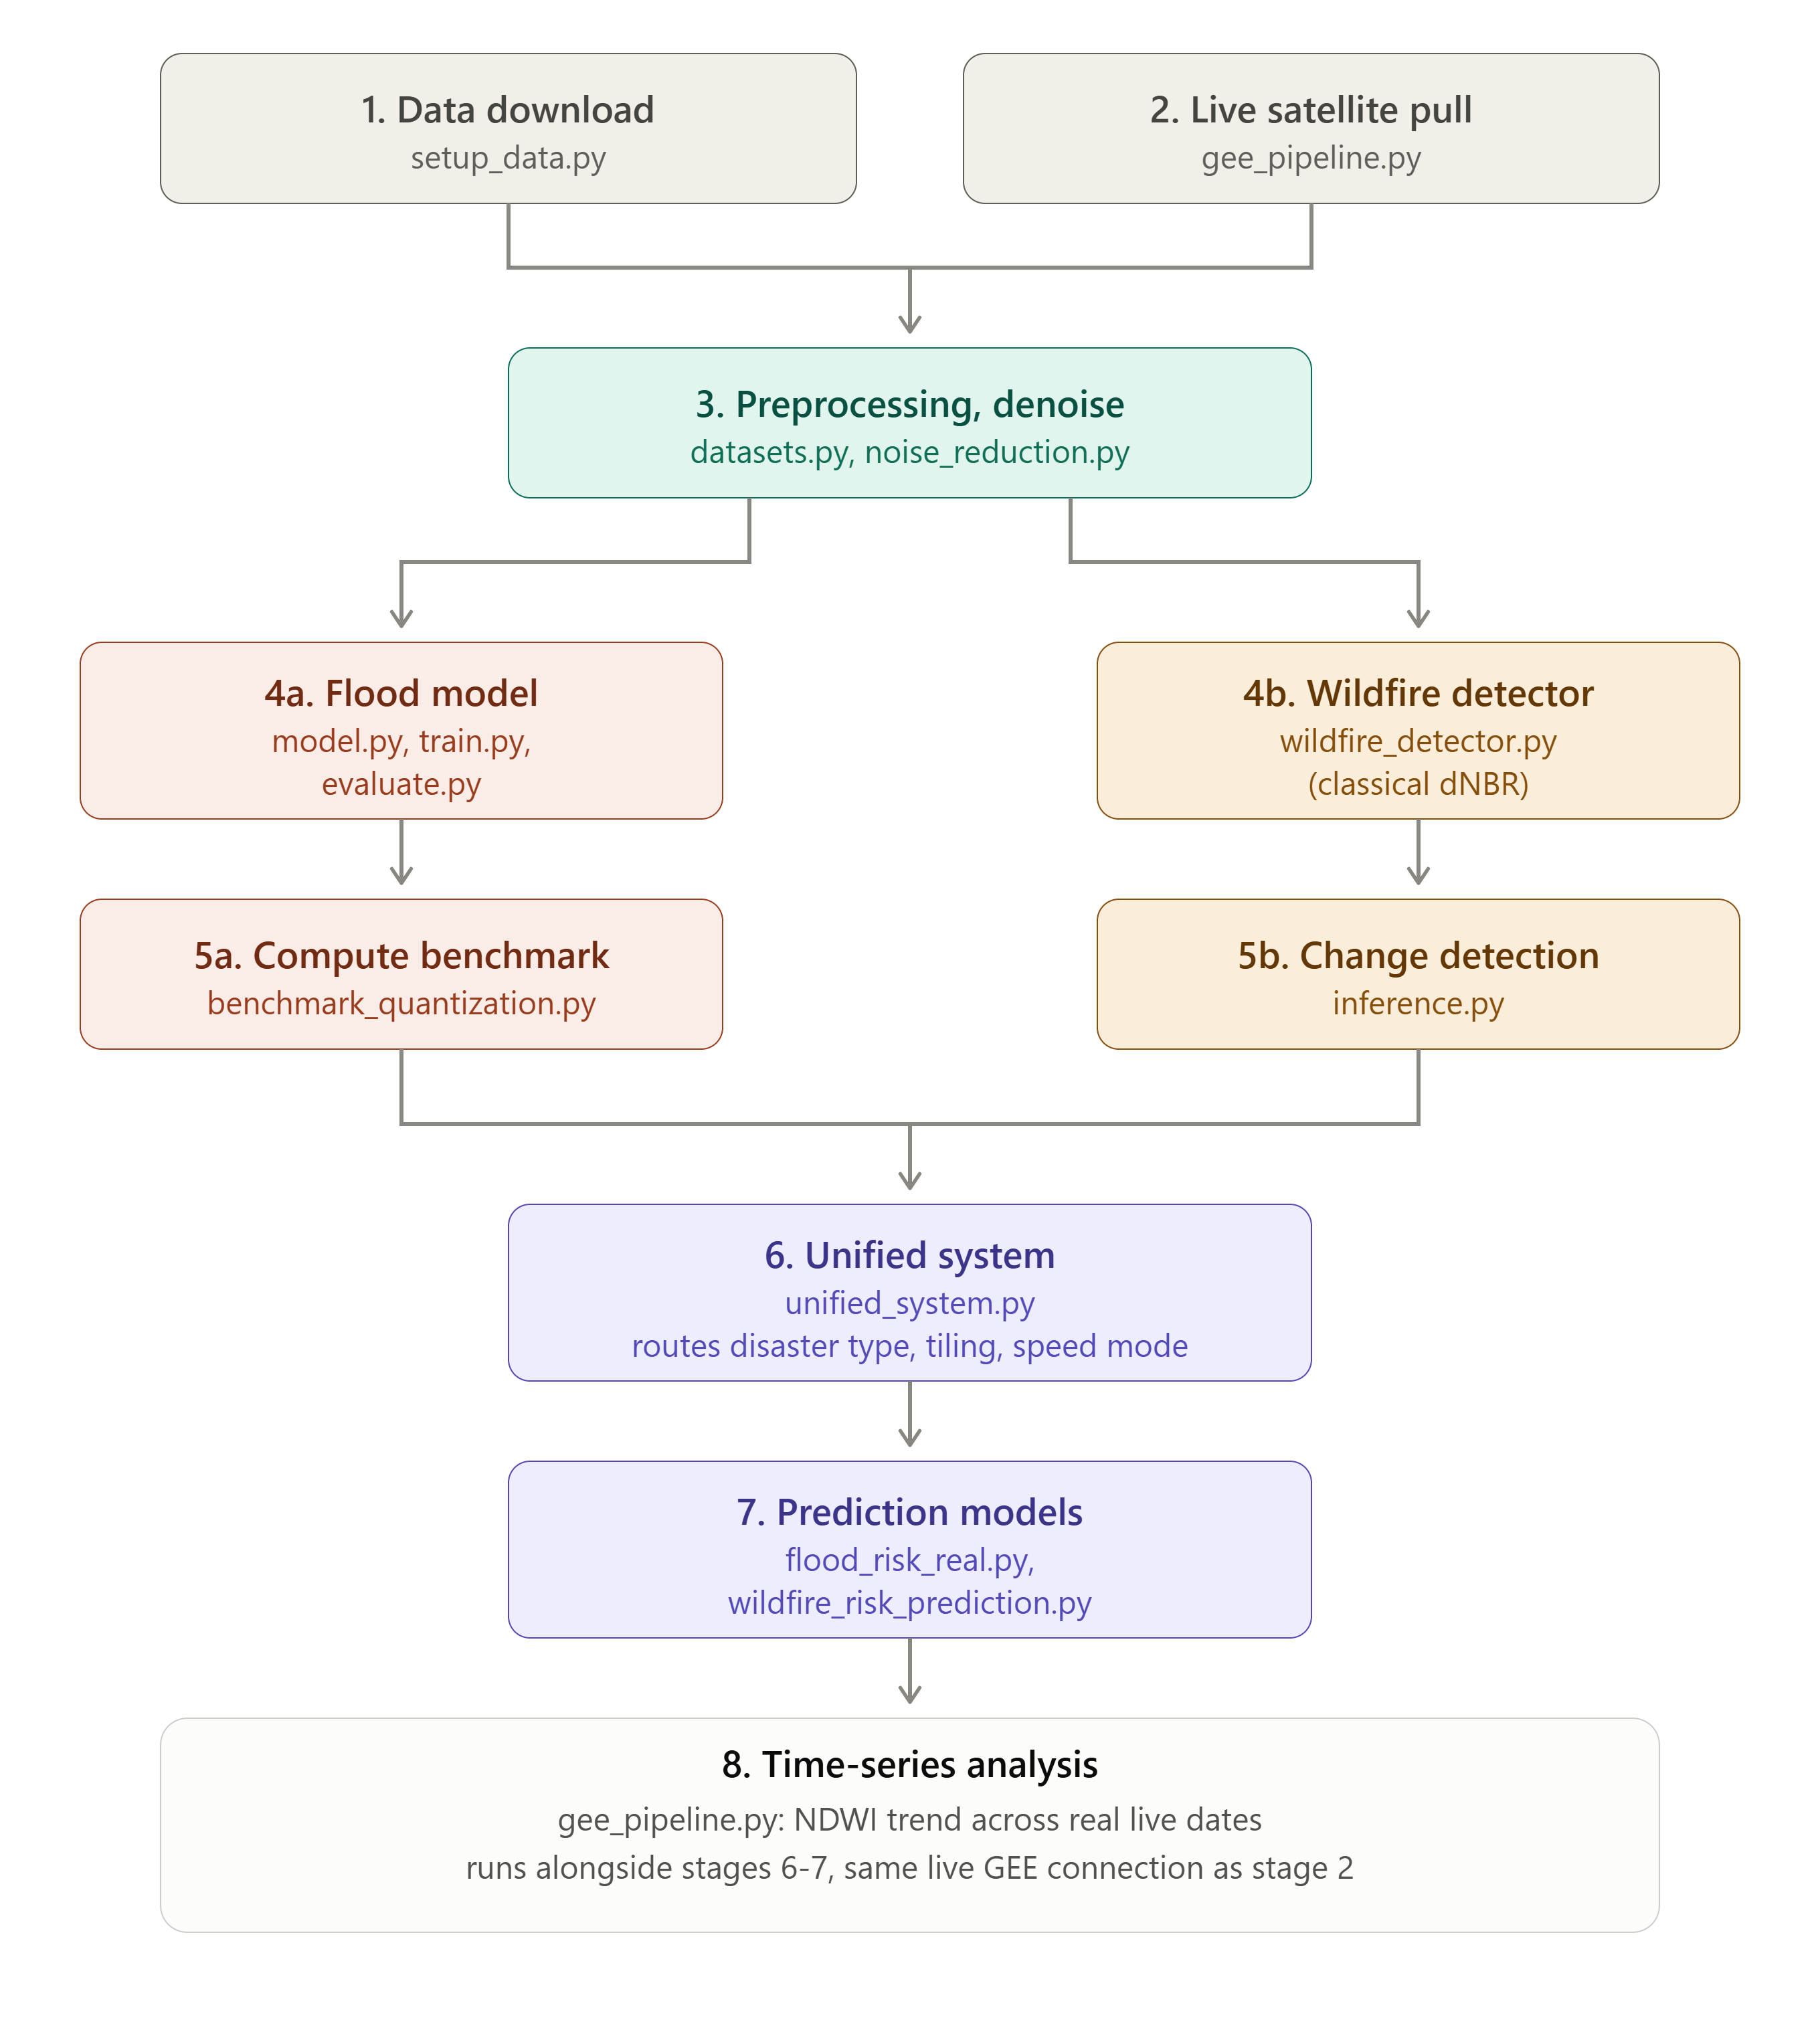

## 0. Setup & security note

In [ ]:
import os

# SECURITY NOTE: an earlier version of this notebook had a real Kaggle API
# token hardcoded here in plaintext. That token has been removed and MUST
# be revoked/rotated at kaggle.com -> Settings -> API if it was ever
# committed or shared. Never hardcode credentials in a notebook you plan
# to share or submit. Set the token via one of these safe methods instead:
#
#   Option A (recommended, doesn't echo the value):
#       import getpass
#       os.environ["KAGGLE_API_TOKEN"] = getpass.getpass("Kaggle API token: ")
#
#   Option B (Colab): upload kaggle.json when prompted by
#       check_kaggle_credentials() below -- no token needs to be typed or
#       stored in this notebook at all.
#
#   Option C (local machine): place kaggle.json at ~/.kaggle/kaggle.json
#       (chmod 600) and skip setting KAGGLE_API_TOKEN entirely.

# Uncomment to use Option A:
# import getpass
# os.environ["KAGGLE_API_TOKEN"] = getpass.getpass("Kaggle API token: ")

os.environ["KAGGLE_API_TOKEN"] = "KGAT_7e69bd7e600b70cfca613516feb182fa"


## 1. Download datasets from Kaggle

Downloads both **Sen1Floods11** (8-channel SAR+optical, flood) and **FloodNet**
(UAV RGB, flood) into `data/`. Needs Kaggle credentials set up above (or a
`kaggle.json` upload prompt if running in Colab).

In [ ]:
"""
setup_data.py
=============
One-time setup: downloads both datasets from Kaggle and unzips them into
the `data/` folder this project expects.

BEFORE running this, you need a Kaggle API key:
  1. Go to kaggle.com -> your profile picture -> Settings
  2. Scroll to "API" -> click "Create New Token" (downloads kaggle.json)
  3. Place it at ~/.kaggle/kaggle.json (Linux/Mac) or
     C:\\Users\\<you>\\.kaggle\\kaggle.json (Windows), or upload it when
     prompted below if running in Colab.
"""

import os
import subprocess
import sys


DATASETS = {
    "sen1floods11": "oindrieelmondal/sen1floods11-8-channel-remote-sensing-dataset",
    "floodnet": "aletbm/aerial-imagery-dataset-floodnet-challenge",
}


def check_kaggle_credentials():
    """
    Kaggle supports two auth methods -- support both so it works regardless
    of which one you set up:
      1. Newer token method: an environment variable KAGGLE_API_TOKEN, or
         a plain-text token saved at ~/.kaggle/access_token
      2. Legacy method: a kaggle.json file at ~/.kaggle/kaggle.json
    """
    if os.environ.get("KAGGLE_API_TOKEN"):
        return True

    token_path = os.path.expanduser("~/.kaggle/access_token")
    if os.path.exists(token_path):
        return True

    legacy_path = os.path.expanduser("~/.kaggle/kaggle.json")
    if os.path.exists(legacy_path):
        return True

    # Running in Google Colab? Offer an interactive setup instead of failing.
    try:
        from google.colab import files  # noqa: F401
        print(
            "No Kaggle credentials found.\n"
            "Paste your token from kaggle.com -> Settings -> API, "
            "or press Enter to upload a kaggle.json file instead.\n"
        )
        token = input("Token (or blank to upload kaggle.json): ").strip()
        os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
        if token:
            with open(token_path, "w") as f:
                f.write(token)
            os.chmod(token_path, 0o600)
        else:
            print("Upload kaggle.json now:")
            uploaded = files.upload()
            for fname in uploaded:
                os.rename(fname, legacy_path)
            os.chmod(legacy_path, 0o600)
        return True
    except ImportError:
        pass

    print(
        "Kaggle credentials not found. Either:\n"
        "  - set the KAGGLE_API_TOKEN environment variable to your token, or\n"
        "  - save your token as plain text to ~/.kaggle/access_token, or\n"
        "  - place a legacy kaggle.json at ~/.kaggle/kaggle.json\n"
        "then re-run this cell."
    )
    return False


def download_dataset(name, kaggle_id):
    out_dir = os.path.join("data", name)
    os.makedirs(out_dir, exist_ok=True)
    print(f"\nDownloading {name} ({kaggle_id}) -> {out_dir}/ ...")
    result = subprocess.run(
        ["kaggle", "datasets", "download", "-d", kaggle_id, "-p", out_dir, "--unzip"],
        capture_output=True, text=True,
    )
    if result.returncode != 0:
        print(f"  FAILED: {result.stderr}")
        return False
    print(f"  Done. Contents:")
    for item in sorted(os.listdir(out_dir))[:10]:
        print(f"    {item}")
    return True


def main():
    if not check_kaggle_credentials():
        sys.exit(1)

    for name, kaggle_id in DATASETS.items():
        download_dataset(name, kaggle_id)

    print(
        "\nNext step: run `find data/ -maxdepth 3 -type d` to see the real "
        "folder layout inside each dataset, then update the --image_dir / "
        "--mask_dir arguments accordingly (the actual subfolder names/depth "
        "may not exactly match this project's defaults)."
    )


main()


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

## 2. Inspect the downloaded folder layout

In [ ]:
!find data/ -maxdepth 4 -type d


In [ ]:
!find "data/floodnet/FloodNet Challenge - Track 1/Train/Labeled" -maxdepth 2
!ls "data/sen1floods11/dataset/Sen1Floods11_8Channel/image" | head -5
!ls "data/sen1floods11/dataset/Sen1Floods11_8Channel/label" | head -5


In [ ]:
!ls "data/floodnet/FloodNet Challenge - Track 1/Train/Labeled/Flooded/image" | head -5
!ls "data/floodnet/FloodNet Challenge - Track 1/Train/Labeled/Flooded/mask" | head -5


## 3. Install remaining dependencies

In [ ]:
!pip install segmentation-models-pytorch rasterio albumentations


## 4. Train the FloodNet U-Net

Binary flood/no-flood segmentation on the 3-channel UAV RGB dataset.

Add `--full_severity --num_classes 10` instead of the defaults below to train
on the full 10-class semantic labels (building/road/water flooded vs.
non-flooded) instead of the collapsed binary mask -- gives real damage-tier
output for Technical Task 5 (damage assessment).

In [ ]:
!python train.py --dataset floodnet \
    --root_dir "data/floodnet/FloodNet Challenge - Track 1/Train/Labeled" \
    --in_channels 3 --epochs 5 --checkpoint floodnet_unet.pt


## 5. Evaluate the trained model

In [ ]:
!python evaluate.py --dataset floodnet \
    --root_dir "data/floodnet/FloodNet Challenge - Track 1/Train/Labeled" \
    --in_channels 3 --checkpoint floodnet_unet.pt


## 6. Benchmark int8 quantization

Concrete numbers for the "limited computational power" requirement: model
size, per-image inference time, and IoU, original vs. quantized.

In [ ]:
!python benchmark_quantization.py --checkpoint floodnet_unet.pt \
    --root_dir "data/floodnet/FloodNet Challenge - Track 1/Train/Labeled" \
    --in_channels 3


## 7. Flood risk *prediction*

Detection (above) finds water that's already visible. This is different:
a lightweight logistic-regression prototype over precursor features
(rainfall trend, soil saturation, river-level trend, elevation) trained on
synthetic-but-realistic example data, structured so real historical data
(e.g. Global Flood Database + precipitation records) could be substituted
in without changing the model code.

In [ ]:
!pip install scikit-learn
!python flood_risk_prediction.py


## 8. Unified system demo — flood, before/after

Single entry point (`unified_system.py`) handling both disaster types, with
a `--mode fast|accurate` tradeoff (accurate now actually denoises using the
bilateral filter in `noise_reduction.py` before inference) and `--tile_size`
for images larger than the model was trained on.

In [ ]:
!ls "data/floodnet/FloodNet Challenge - Track 1/Train/Labeled/Non-Flooded/image" | head -3
!ls "data/floodnet/FloodNet Challenge - Track 1/Train/Labeled/Flooded/image" | head -3


In [ ]:
!python unified_system.py --disaster_type flood \
    --before "data/floodnet/FloodNet Challenge - Track 1/Train/Labeled/Non-Flooded/image/10175.jpg" \
    --after "data/floodnet/FloodNet Challenge - Track 1/Train/Labeled/Flooded/image/10165.jpg" \
    --checkpoint floodnet_unet.pt --in_channels 3 --mode accurate


In [ ]:
!python unified_system.py --disaster_type flood \
    --before "data/floodnet/FloodNet Challenge - Track 1/Train/Labeled/Non-Flooded/image/10175.jpg" \
    --after "data/floodnet/FloodNet Challenge - Track 1/Train/Labeled/Flooded/image/10165.jpg" \
    --checkpoint floodnet_unet.pt --in_channels 3 --mode fast


## 9. Wildfire burn-severity demo

Classical dNBR (Normalized Burn Ratio difference) approach — no training
run needed. Requires a real before/after Sentinel-2 GeoTIFF pair with known
NIR/SWIR band indices (see the Earth Engine section below for how to pull
one). Now outputs **tiered severity** (unburned/low/moderate-low/
moderate-high/high, USGS convention) instead of a single binary mask, and
`--denoise` applies the bilateral filter before computing NBR.

In [ ]:
# # Uncomment once you have real before/after GeoTIFFs (see section 10 for
# # download_sentinel2_geotiff, which produces files usable here):
# #
# !python unified_system.py --disaster_type wildfire \
#     --before before_fire.tif --after after_fire.tif \
#     --nir_band 0 --swir_band 2 --mode accurate


## 10. Google Earth Engine — live time-series & before/after pull

Two things this section adds beyond the downloaded Kaggle images:

- **Time-series analysis** (Technical Task 1): NDWI trend over real dates,
  not just a single snapshot.
- **Live inference inputs**: a real before/after Sentinel-1 pair, or a
  downloaded Sentinel-2 GeoTIFF pair usable by `wildfire_detector.py`.

Run the authentication cell once per session.

In [ ]:
import ee
ee.Authenticate()
ee.Initialize(project='disaster-project-508518')
print(ee.Number(1).getInfo())


In [ ]:
from gee_pipeline import get_ndwi_time_series

dates, values = get_ndwi_time_series(31.5497, 74.3436, days_back=60)
for d, v in zip(dates, values):
    print(d, v)


Optional: download a real Sentinel-2 before/after GeoTIFF pair to feed
into the wildfire demo in section 9.

In [ ]:
from gee_pipeline import download_sentinel2_geotiff
#
download_sentinel2_geotiff(34.05, -118.5, "2025-01-01", "before_fire.tif")
download_sentinel2_geotiff(34.05, -118.5, "2025-02-01", "after_fire.tif")


In [ ]:
!python unified_system.py --disaster_type wildfire \
    --before before_fire.tif --after after_fire.tif \
    --nir_band 0 --swir_band 2 --mode accurate

In [ ]:
import rasterio
import matplotlib.pyplot as plt
import numpy as np

with rasterio.open("results/burn_severity_severity.tif") as src:
    severity = src.read(1)

labels = ["unburned", "low", "moderate_low", "moderate_high", "high"]
cmap = plt.cm.get_cmap("YlOrRd", 5)

plt.figure(figsize=(8, 8))
im = plt.imshow(severity, cmap=cmap, vmin=0, vmax=4)
cbar = plt.colorbar(im, ticks=range(5))
cbar.ax.set_yticklabels(labels)
plt.title("Wildfire Burn Severity — LA, Jan-Feb 2025")
plt.axis("off")
plt.savefig("results/severity_map.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
!python unified_system.py --disaster_type wildfire \
    --before before_fire.tif --after after_fire.tif \
    --nir_band 0 --swir_band 2 --mode fast

In [ ]:
!python train.py --dataset sen1floods11 \
    --image_dir "data/sen1floods11/dataset/Sen1Floods11_8Channel/image" \
    --mask_dir "data/sen1floods11/dataset/Sen1Floods11_8Channel/label" \
    --in_channels 8 --epochs 3 --checkpoint sen1floods_unet.pt

In [ ]:
!python train.py --dataset floodnet \
    --root_dir "data/floodnet/FloodNet Challenge - Track 1/Train/Labeled" \
    --in_channels 3 --epochs 5 --full_severity --num_classes 10 --checkpoint floodnet_severity.pt

In [ ]:
import rasterio
import matplotlib.pyplot as plt

with rasterio.open("results/burn_severity_severity.tif") as src:
    severity = src.read(1)

labels = ["unburned", "low", "moderate_low", "moderate_high", "high"]
cmap = plt.cm.get_cmap("YlOrRd", 5)
plt.figure(figsize=(8, 8))
im = plt.imshow(severity, cmap=cmap, vmin=0, vmax=4)
cbar = plt.colorbar(im, ticks=range(5))
cbar.ax.set_yticklabels(labels)
plt.title("Wildfire Burn Severity — LA, Jan-Feb 2025")
plt.axis("off")
plt.savefig("results/severity_map.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
!python unified_system.py --disaster_type wildfire \
    --before before_fire.tif --after after_fire.tif \
    --nir_band 0 --swir_band 2 --mode fast

In [ ]:
import rasterio
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
for ax, path, title in zip(axes, ["before_fire.tif", "after_fire.tif"], ["Before", "After"]):
    with rasterio.open(path) as src:
        img = src.read([1, 2, 3]).astype(np.float32)  # B8, B4, B12
        img = np.transpose(img, (1, 2, 0))
        img = (img - img.min()) / (img.max() - img.min() + 1e-6)  # normalize for display
    ax.imshow(img)
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.savefig("results/before_after_preview.png", dpi=150)
plt.show()

In [ ]:
!ls *.py

In [ ]:
!pip install ucimlrepo
!python wildfire_risk_prediction.py

In [ ]:
import ee
ee.Authenticate()
ee.Initialize(project='disaster-project-508518')

In [ ]:
!grep -n "def get_current_ndwi" /content/gee_pipeline.py

In [ ]:
import ee
ee.Authenticate()
ee.Initialize(project='disaster-project-508518')
print(ee.Number(1).getInfo())  # should print 1

In [ ]:
# 33333
!python -u flood_prediction_v2.py --n_events 60 --days_back 30

In [ ]:
!python gen_charts.py